# CS3807 Experiment 5 — Remaining Tasks
This notebook picks up from where the previous session left off.
**Plots 1–8 are already done** (saved as images from earlier runs) — this notebook only covers:
- Task 6 remaining: Plot 9 (Batch Size), Plot 10 (Dropout Rate)
- Task 7: Transfer Learning / Fine-Tuning (Plots 11–12)

⚠️ **Restart points are marked clearly below.** Restart the runtime (`Runtime → Restart session`) at each marked point, then continue from the next cell — do not skip Step 0 after a restart, or Drive won't be mounted and `save_result` will fail.


## Step 0 — Run this FIRST in every fresh runtime (mount Drive + checkpoint helpers)

In [5]:
from google.colab import drive
drive.mount('/content/drive', force_remount=True)

import pickle, os
CKPT_DIR = '/content/drive/MyDrive/CS3807_Exp5'
os.makedirs(CKPT_DIR, exist_ok=True)

def save_result(name, data):
    path = os.path.join(CKPT_DIR, f"{name}.pkl")
    with open(path, 'wb') as f:
        pickle.dump(data, f)
    print(f"Saved: {path}")

def load_result(name):
    with open(os.path.join(CKPT_DIR, f"{name}.pkl"), 'rb') as f:
        return pickle.load(f)

def list_saved():
    return sorted(f for f in os.listdir(CKPT_DIR) if f.endswith('.pkl'))

print("Already saved:", list_saved())

Mounted at /content/drive
Already saved: []


## Step 1 — Installs (once per fresh VM)\nAfter this cell finishes: **Runtime → Restart session**, then re-run Step 0 above before continuing.

In [ ]:
!pip install -U -q protobuf tensorflow-datasets tensorflow-metadata importlib_resources

## Step 2 — Task 1 Setup (dataset + preprocessing)\nRun this every fresh session. The dataset itself is cached on Google's servers per-VM, so this is quick, but note a brand-new Colab VM will re-download it once.

In [ ]:
import tensorflow as tf
import tensorflow_datasets as tfds
import numpy as np
import matplotlib.pyplot as plt

print("TF version:", tf.__version__)
print("GPU available:", tf.config.list_physical_devices('GPU'))

IMG_SIZE = 224
BATCH_SIZE = 32
SEED = 42

(ds_train_full, ds_test), ds_info = tfds.load(
    'oxford_iiit_pet',
    split=['train', 'test'],
    with_info=True,
    as_supervised=True
)

num_classes = ds_info.features['label'].num_classes
print("Number of classes (breeds):", num_classes)

train_size = int(0.8 * ds_info.splits['train'].num_examples)
ds_train_full = ds_train_full.shuffle(1000, seed=SEED)
ds_train = ds_train_full.take(train_size)
ds_val = ds_train_full.skip(train_size)

def preprocess(image, label, augment=False):
    image = tf.image.resize(image, (IMG_SIZE, IMG_SIZE))
    if augment:
        image = tf.image.random_flip_left_right(image)
    image = tf.keras.applications.mobilenet_v2.preprocess_input(image)
    label = tf.one_hot(label, num_classes)
    return image, label

def make_pipeline(ds, shuffle=False, augment=False):
    if shuffle:
        ds = ds.shuffle(1000, seed=SEED)
    ds = ds.map(lambda x, y: preprocess(x, y, augment), num_parallel_calls=tf.data.AUTOTUNE)
    ds = ds.batch(BATCH_SIZE)
    ds = ds.prefetch(tf.data.AUTOTUNE)
    return ds

train_ds = make_pipeline(ds_train, shuffle=True, augment=True)
val_ds   = make_pipeline(ds_val)
test_ds  = make_pipeline(ds_test)

class_names = ds_info.features['label'].names
print("Setup complete. Train size:", train_size)


TF version: 2.20.0
GPU available: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]
Number of classes (breeds): 37
Setup complete. Train size: 2944


---
## Task 6 (continued) — Plot 9: Batch Size vs Validation Accuracy


In [6]:
from tensorflow.keras import layers, models
import gc

EPOCHS_HP = 10

def build_hp_model(dropout_rate):
    base_model = tf.keras.applications.MobileNetV2(
        input_shape=(IMG_SIZE, IMG_SIZE, 3), include_top=False, weights='imagenet')
    base_model.trainable = False
    inputs = tf.keras.Input(shape=(IMG_SIZE, IMG_SIZE, 3))
    x = base_model(inputs, training=False)
    x = layers.GlobalAveragePooling2D()(x)
    x = layers.Dense(128, activation='relu')(x)
    if dropout_rate > 0:
        x = layers.Dropout(dropout_rate)(x)
    outputs = layers.Dense(num_classes, activation='softmax')(x)
    return models.Model(inputs, outputs)

batch_sizes = [16, 32, 64]
bs_results = {}

for bs in batch_sizes:
    print(f"\n--- Batch Size: {bs} ---")
    train_ds_bs = ds_train.shuffle(1000, seed=SEED).map(
        lambda x, y: preprocess(x, y, augment=True), num_parallel_calls=tf.data.AUTOTUNE
    ).batch(bs).prefetch(tf.data.AUTOTUNE)
    val_ds_bs = ds_val.map(
        lambda x, y: preprocess(x, y, augment=False), num_parallel_calls=tf.data.AUTOTUNE
    ).batch(bs).prefetch(tf.data.AUTOTUNE)

    tf.keras.backend.clear_session(); gc.collect()
    model = build_hp_model(dropout_rate=0.25)
    model.compile(optimizer=tf.keras.optimizers.Adam(learning_rate=1e-3),
                  loss='categorical_crossentropy', metrics=['accuracy'])
    history = model.fit(train_ds_bs, validation_data=val_ds_bs, epochs=EPOCHS_HP, verbose=1)
    bs_results[bs] = max(history.history['val_accuracy']) * 100

    save_result('bs_results_partial', bs_results)
    del model, history, train_ds_bs, val_ds_bs
    tf.keras.backend.clear_session(); gc.collect()

save_result('bs_results_final', bs_results)
print(bs_results)



--- Batch Size: 16 ---
Epoch 1/10
184/184 ━━━━━━━━━━━━━━━━━━━━ 33s 107ms/step - accuracy: 0.7075 - loss: 1.1280 - val_accuracy: 0.9076 - val_loss: 0.3461
Epoch 2/10
184/184 ━━━━━━━━━━━━━━━━━━━━ 20s 83ms/step - accuracy: 0.8852 - loss: 0.3600 - val_accuracy: 0.9389 - val_loss: 0.2036
Epoch 3/10
184/184 ━━━━━━━━━━━━━━━━━━━━ 20s 82ms/step - accuracy: 0.9171 - loss: 0.2417 - val_accuracy: 0.9538 - val_loss: 0.1452
Epoch 4/10
184/184 ━━━━━━━━━━━━━━━━━━━━ 18s 80ms/step - accuracy: 0.9433 - loss: 0.1820 - val_accuracy: 0.9592 - val_loss: 0.1299
Epoch 5/10
184/184 ━━━━━━━━━━━━━━━━━━━━ 20s 83ms/step - accuracy: 0.9528 - loss: 0.1444 - val_accuracy: 0.9742 - val_loss: 0.0846
Epoch 6/10
184/184 ━━━━━━━━━━━━━━━━━━━━ 19s 81ms/step - accuracy: 0.9640 - loss: 0.1221 - val_accuracy: 0.9728 - val_loss: 0.0933
Epoch 7/10
184/184 ━━━━━━━━━━━━━━━━━━━━ 18s 81ms/step - accuracy: 0.9715 - loss: 0.0990 - val_accuracy: 0.9796 - val_loss: 0.0713
Epoch 8/10
184/184 ━━━━━━━━━━━━━━━━━━━━ 20s 81ms/step - accuracy:

In [ ]:
plt.figure(figsize=(7, 5))
plt.plot(list(bs_results.keys()), list(bs_results.values()), marker='o')
plt.xlabel('Batch Size')
plt.ylabel('Best Validation Accuracy (%)')
plt.title('Plot 9: Batch Size vs Validation Accuracy')
plt.grid(True, alpha=0.3)
plt.savefig('plot9_batchsize_valacc.png', dpi=150, bbox_inches='tight')
plt.show()


---
⚠️ **RESTART POINT** — Runtime → Restart session, then re-run Step 0, Step 2 (Task 1 setup), before continuing to Plot 10.


## Task 6 (continued) — Plot 10: Dropout Rate vs Validation Accuracy
Requires `build_hp_model` from the Plot 9 cell above — if you restarted, run that function definition cell again (just the `def build_hp_model` part) or re-run the whole Plot 9 code cell (it will just redo the sweep; comment it out if you already have `bs_results_final` saved and don't want to redo it).


In [ ]:
from tensorflow.keras import layers, models
import gc

EPOCHS_HP = 10

def build_hp_model(dropout_rate):
    base_model = tf.keras.applications.MobileNetV2(
        input_shape=(IMG_SIZE, IMG_SIZE, 3), include_top=False, weights='imagenet')
    base_model.trainable = False
    inputs = tf.keras.Input(shape=(IMG_SIZE, IMG_SIZE, 3))
    x = base_model(inputs, training=False)
    x = layers.GlobalAveragePooling2D()(x)
    x = layers.Dense(128, activation='relu')(x)
    if dropout_rate > 0:
        x = layers.Dropout(dropout_rate)(x)
    outputs = layers.Dense(num_classes, activation='softmax')(x)
    return models.Model(inputs, outputs)

dropout_rates = [0, 0.25, 0.5]
dropout_results = {}

for dr in dropout_rates:
    print(f"\n--- Dropout Rate: {dr} ---")
    tf.keras.backend.clear_session(); gc.collect()
    model = build_hp_model(dropout_rate=dr)
    model.compile(optimizer=tf.keras.optimizers.Adam(learning_rate=1e-3),
                  loss='categorical_crossentropy', metrics=['accuracy'])
    history = model.fit(train_ds, validation_data=val_ds, epochs=EPOCHS_HP, verbose=1)
    dropout_results[dr] = max(history.history['val_accuracy']) * 100

    save_result('dropout_results_partial', dropout_results)
    del model, history
    tf.keras.backend.clear_session(); gc.collect()

save_result('dropout_results_final', dropout_results)
print(dropout_results)


In [ ]:
plt.figure(figsize=(7, 5))
plt.plot(list(dropout_results.keys()), list(dropout_results.values()), marker='o')
plt.xlabel('Dropout Rate')
plt.ylabel('Best Validation Accuracy (%)')
plt.title('Plot 10: Dropout Rate vs Validation Accuracy')
plt.grid(True, alpha=0.3)
plt.savefig('plot10_dropout_valacc.png', dpi=150, bbox_inches='tight')
plt.show()


---
⚠️ **RESTART POINT** — Runtime → Restart session, then re-run Step 0 and Step 2 before continuing to Task 7.

## Task 7 — Transfer Learning and Fine-Tuning (Plots 11–12)
**Case A (Feature Extraction):** base frozen, only new classifier head trained.
**Case B (Fine-Tuning):** unfreeze the top layers of the pretrained base, train with a much smaller learning rate.


In [7]:
from tensorflow.keras import layers, models
import gc

EPOCHS_FE = 10   # feature extraction phase
EPOCHS_FT = 10   # fine-tuning phase

# ---- Case A: Feature Extraction ----
tf.keras.backend.clear_session(); gc.collect()

base_model = tf.keras.applications.MobileNetV2(
    input_shape=(IMG_SIZE, IMG_SIZE, 3), include_top=False, weights='imagenet')
base_model.trainable = False

inputs = tf.keras.Input(shape=(IMG_SIZE, IMG_SIZE, 3))
x = base_model(inputs, training=False)
x = layers.GlobalAveragePooling2D()(x)
x = layers.Dense(128, activation='relu')(x)
x = layers.Dropout(0.25)(x)
outputs = layers.Dense(num_classes, activation='softmax')(x)
model = models.Model(inputs, outputs)

model.compile(optimizer=tf.keras.optimizers.Adam(learning_rate=1e-3),
              loss='categorical_crossentropy', metrics=['accuracy'])

print("=== Feature Extraction ===")
history_fe = model.fit(train_ds, validation_data=val_ds, epochs=EPOCHS_FE, verbose=1)

save_result('history_feature_extraction', history_fe.history)


=== Feature Extraction ===
Epoch 1/10
92/92 ━━━━━━━━━━━━━━━━━━━━ 33s 209ms/step - accuracy: 0.6240 - loss: 1.4669 - val_accuracy: 0.9144 - val_loss: 0.3416
Epoch 2/10
92/92 ━━━━━━━━━━━━━━━━━━━━ 30s 154ms/step - accuracy: 0.8740 - loss: 0.4098 - val_accuracy: 0.9226 - val_loss: 0.2380
Epoch 3/10
92/92 ━━━━━━━━━━━━━━━━━━━━ 21s 171ms/step - accuracy: 0.9147 - loss: 0.2751 - val_accuracy: 0.9470 - val_loss: 0.1607
Epoch 4/10
92/92 ━━━━━━━━━━━━━━━━━━━━ 18s 154ms/step - accuracy: 0.9341 - loss: 0.2200 - val_accuracy: 0.9660 - val_loss: 0.1319
Epoch 5/10
92/92 ━━━━━━━━━━━━━━━━━━━━ 21s 184ms/step - accuracy: 0.9457 - loss: 0.1782 - val_accuracy: 0.9742 - val_loss: 0.0928
Epoch 6/10
92/92 ━━━━━━━━━━━━━━━━━━━━ 20s 172ms/step - accuracy: 0.9671 - loss: 0.1197 - val_accuracy: 0.9796 - val_loss: 0.0799
Epoch 7/10
92/92 ━━━━━━━━━━━━━━━━━━━━ 18s 156ms/step - accuracy: 0.9664 - loss: 0.1062 - val_accuracy: 0.9783 - val_loss: 0.0659
Epoch 8/10
92/92 ━━━━━━━━━━━━━━━━━━━━ 20s 156ms/step - accuracy: 0.969

In [8]:
# ---- Case B: Fine-Tuning ----
# Unfreeze the top N layers of the base model, keep the rest frozen
base_model.trainable = True

fine_tune_at = len(base_model.layers) - 30  # unfreeze last ~30 layers
for layer in base_model.layers[:fine_tune_at]:
    layer.trainable = False

# Much smaller learning rate for fine-tuning, per the lab doc's guidance
model.compile(optimizer=tf.keras.optimizers.Adam(learning_rate=1e-5),
              loss='categorical_crossentropy', metrics=['accuracy'])

print("=== Fine-Tuning ===")
history_ft = model.fit(train_ds, validation_data=val_ds, epochs=EPOCHS_FT, verbose=1)

save_result('history_fine_tuning', history_ft.history)


=== Fine-Tuning ===
Epoch 1/10
92/92 ━━━━━━━━━━━━━━━━━━━━ 42s 226ms/step - accuracy: 0.9110 - loss: 0.2661 - val_accuracy: 0.9973 - val_loss: 0.0252
Epoch 2/10
92/92 ━━━━━━━━━━━━━━━━━━━━ 25s 165ms/step - accuracy: 0.9372 - loss: 0.1963 - val_accuracy: 0.9973 - val_loss: 0.0243
Epoch 3/10
92/92 ━━━━━━━━━━━━━━━━━━━━ 21s 164ms/step - accuracy: 0.9538 - loss: 0.1548 - val_accuracy: 0.9959 - val_loss: 0.0262
Epoch 4/10
92/92 ━━━━━━━━━━━━━━━━━━━━ 18s 158ms/step - accuracy: 0.9586 - loss: 0.1386 - val_accuracy: 0.9932 - val_loss: 0.0292
Epoch 5/10
92/92 ━━━━━━━━━━━━━━━━━━━━ 19s 164ms/step - accuracy: 0.9626 - loss: 0.1315 - val_accuracy: 0.9946 - val_loss: 0.0277
Epoch 6/10
92/92 ━━━━━━━━━━━━━━━━━━━━ 20s 163ms/step - accuracy: 0.9667 - loss: 0.1183 - val_accuracy: 0.9932 - val_loss: 0.0264
Epoch 7/10
92/92 ━━━━━━━━━━━━━━━━━━━━ 18s 156ms/step - accuracy: 0.9698 - loss: 0.1036 - val_accuracy: 0.9973 - val_loss: 0.0168
Epoch 8/10
92/92 ━━━━━━━━━━━━━━━━━━━━ 19s 163ms/step - accuracy: 0.9691 - los

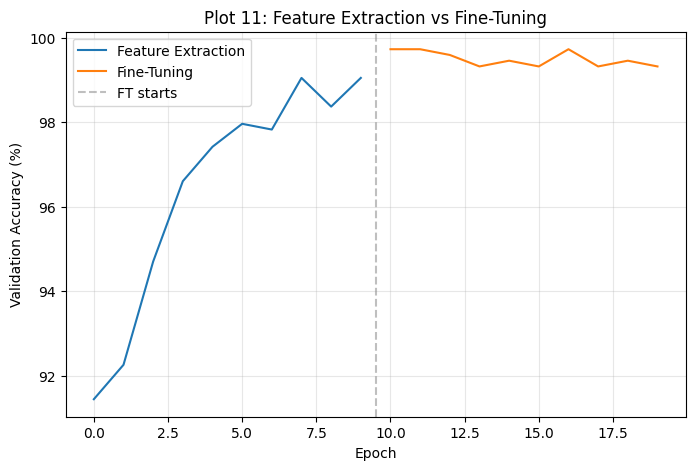

In [9]:
# ---- Plot 11: Feature Extraction vs Fine-Tuning ----
fe_acc = [a * 100 for a in history_fe.history['val_accuracy']]
ft_acc = [a * 100 for a in history_ft.history['val_accuracy']]
# Fine-tuning continues from where feature extraction left off, in terms of epoch count
ft_epochs = list(range(len(fe_acc), len(fe_acc) + len(ft_acc)))

plt.figure(figsize=(8, 5))
plt.plot(range(len(fe_acc)), fe_acc, label='Feature Extraction')
plt.plot(ft_epochs, ft_acc, label='Fine-Tuning')
plt.axvline(x=len(fe_acc)-0.5, color='gray', linestyle='--', alpha=0.5, label='FT starts')
plt.xlabel('Epoch')
plt.ylabel('Validation Accuracy (%)')
plt.title('Plot 11: Feature Extraction vs Fine-Tuning')
plt.legend()
plt.grid(True, alpha=0.3)
plt.savefig('plot11_fe_vs_ft.png', dpi=150, bbox_inches='tight')
plt.show()


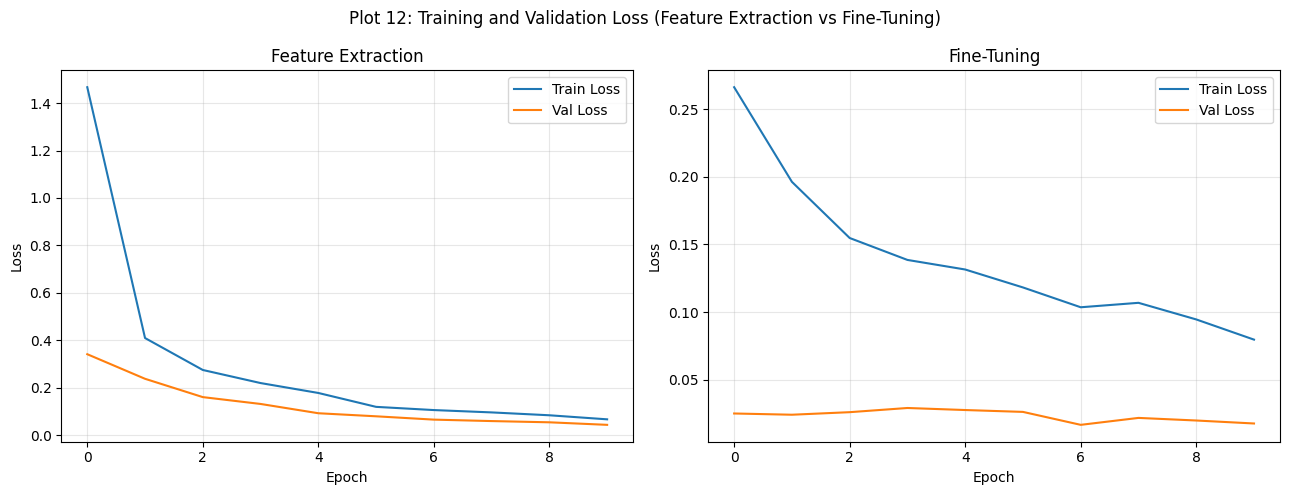

Model saved to Drive.


In [10]:
# ---- Plot 12: Training and Validation Loss (before vs after fine-tuning) ----
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

axes[0].plot(history_fe.history['loss'], label='Train Loss')
axes[0].plot(history_fe.history['val_loss'], label='Val Loss')
axes[0].set_title('Feature Extraction')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Loss')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

axes[1].plot(history_ft.history['loss'], label='Train Loss')
axes[1].plot(history_ft.history['val_loss'], label='Val Loss')
axes[1].set_title('Fine-Tuning')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Loss')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.suptitle('Plot 12: Training and Validation Loss (Feature Extraction vs Fine-Tuning)')
plt.tight_layout()
plt.savefig('plot12_fe_ft_loss.png', dpi=150, bbox_inches='tight')
plt.show()

# Save the fine-tuned model in case Task 8/9 need it later
model.save('/content/drive/MyDrive/CS3807_Exp5/finetuned_model.keras')
print("Model saved to Drive.")


---
### Discussion note for Plot 11/12 (the doc asks you to explain this)
Fine-tuning uses a **much smaller learning rate (1e-5 vs 1e-3)** because the unfrozen base layers already hold well-tuned ImageNet weights — large updates at this stage would wreck those pretrained features ("catastrophic forgetting") rather than gently adapting them to the pet-breed task.

---
**Next:** once Plots 11–12 look right, download them and we'll move to **Task 8: 5-Fold Cross-Validation (Plot 13)**.
